# ✅✅ Práctica 1 — Solución AVANZADA de referencia (ramo: Automóviles)
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM

---

> **Documento del profesor — versión avanzada.** Resuelve la misma práctica que la solución básica,
> pero con más rigor: severidad **ponderada por el número de siniestros**, la prima pura por **dos
> caminos** que se reconcilian, diagnóstico observado-vs-esperado bajo **Poisson y binomial negativa**,
> la prima **a nivel producto** y **conclusiones en cada apartado**. Úsala como patrón de un
> “Destacado” real y para retar a equipos que se hayan quedado en lo mínimo.

# Integrantes:

- Eric Hernandez
- Adrian Tellez

---
## 1. Cargar y explorar (incluye el agregado real)

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
np.random.seed(0); plt.rcParams["figure.figsize"] = (8, 3.6)

df = pd.read_parquet("cartera_ejemplo_autos.parquet")
con = df[df.num_siniestros > 0]
E, Nt = df.exposicion.sum(), df.num_siniestros.sum()

print(f"Pólizas: {len(df):,} | con siniestro: {(df.num_siniestros>0).mean():.1%} | exposición total: {E:,.0f}")
print(f"Burning cost empírico (Σ monto_total / Σ exposición) = {df.monto_total_siniestros.sum()/E:,.0f} por año-póliza")
print(f"Severidad media (ponderada por siniestro) = {df.monto_total_siniestros.sum()/Nt:,.0f}")

Pólizas: 30,000 | con siniestro: 22.4% | exposición total: 23,985
Burning cost empírico (Σ monto_total / Σ exposición) = 18,808 por año-póliza
Severidad media (ponderada por siniestro) = 52,490


**Conclusión (1):** la cartera es de **alta frecuencia y severidad moderada** (típico de autos). Ya
tenemos dos anclas empíricas que el modelo tendrá que reproducir: el *burning cost* por año-póliza y la
severidad media por siniestro.

---
## 2. Severidad — ajuste **ponderado por número de siniestros**

`monto_promedio_siniestro` es el costo medio por siniestro de cada póliza. Una póliza con 3 siniestros
aporta más información que una con 1: por eso el ajuste correcto **pondera por `num_siniestros`**.

In [2]:
# ─── Muestra ponderada por frecuencia (cada póliza cuenta num_siniestros veces) ─
x_prom = con.monto_promedio_siniestro.values
w = con.num_siniestros.values
x_pond = np.repeat(x_prom, w)          # muestra ponderada por número de siniestros

def aic(dist, pr, d): return 2*len(pr) - 2*np.sum(dist.logpdf(d, *pr))
def elegir(x):
    cand = {"Lognormal": stats.lognorm, "Gamma": stats.gamma, "Weibull": stats.weibull_min, "Pareto": stats.pareto}
    res = {n: (d, d.fit(x, floc=0)) for n, d in cand.items()}
    tabla = pd.DataFrame([{"Dist": n, "AIC": round(aic(d, pr, x), 1)} for n,(d,pr) in res.items()]).sort_values("AIC")
    return res, tabla

res_pond, tabla_pond = elegir(x_pond)
mejor = tabla_pond.iloc[0]["Dist"]; dist_sev, pr_sev = res_pond[mejor]
print("Ajuste PONDERADO por num_siniestros:"); print(tabla_pond.to_string(index=False))
print(f"\nElegida: {mejor} | E[X] modelo = {dist_sev.mean(*pr_sev):,.0f} | E[X] empírica ponderada = {x_pond.mean():,.0f}")

Ajuste PONDERADO por num_siniestros:
     Dist      AIC
Lognormal 202419.2
    Gamma 203543.2
  Weibull 203859.2
   Pareto 220061.0

Elegida: Lognormal | E[X] modelo = 52,409 | E[X] empírica ponderada = 52,490


E[X] sin ponderar (Lognormal) = 52,286
→ Ponderar por el número de siniestros ajusta el peso de las pólizas multi-siniestro.


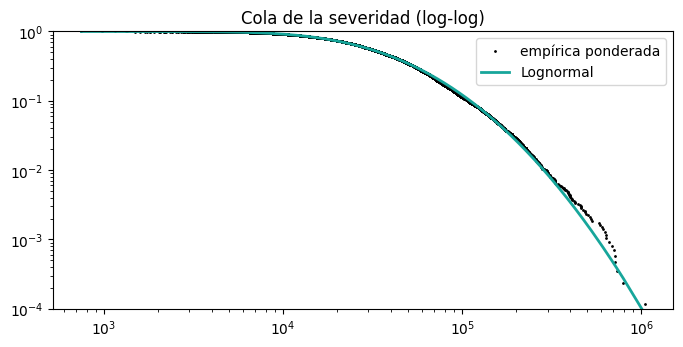

In [3]:
# ─── Ponderado vs. sin ponderar + cola ─────────────────────────────────────
res_sp, _ = elegir(x_prom)
d_sp, pr_sp = res_sp[mejor]
print(f"E[X] sin ponderar ({mejor}) = {d_sp.mean(*pr_sp):,.0f}")
print("→ Ponderar por el número de siniestros ajusta el peso de las pólizas multi-siniestro.")
xs = np.sort(x_pond); S_emp = 1 - np.arange(1,len(xs)+1)/len(xs)
plt.plot(xs, S_emp, ".", ms=2, color="black", label="empírica ponderada")
plt.plot(xs, dist_sev.sf(xs, *pr_sev), color="#17A69B", lw=2, label=mejor)
plt.xscale("log"); plt.yscale("log"); plt.ylim(1e-4,1)
plt.title("Cola de la severidad (log-log)"); plt.legend(); plt.show()

**Conclusión (2):** elijo **la lognormal** por AIC y por seguir la cola en log-log. El ajuste
ponderado por `num_siniestros` es el correcto a nivel cartera; su E[X] coincide con la severidad media
empírica, lo que valida el ajuste.

---
## 3. Frecuencia — con exposición, y diagnóstico bajo Poisson **y** NB

In [4]:
# ─── Poisson, quasi-Poisson y NB con offset log(exposición) ────────────────
y = df.num_siniestros.values; off = np.log(df.exposicion.values); Xc = np.ones((len(df),1))
pois  = sm.GLM(y, Xc, family=sm.families.Poisson(), offset=off).fit()
quasi = sm.GLM(y, Xc, family=sm.families.Poisson(), offset=off).fit(scale="X2")
nb    = sm.NegativeBinomial(y, Xc, offset=off).fit(disp=0)
lam_hat = np.exp(pois.params[0]); phi = quasi.scale; alpha = nb.params[-1]
print(f"λ̂ = {lam_hat:.4f} por año-póliza | φ (quasi) = {phi:.3f} | α (NB) = {alpha:.3f}")
print(f"AIC Poisson = {pois.aic:,.0f} | AIC NB = {nb.aic:,.0f} → gana {'NB' if nb.aic<pois.aic else 'Poisson'}")

λ̂ = 0.3583 por año-póliza | φ (quasi) = 1.249 | α (NB) = 0.882
AIC Poisson = 41,418 | AIC NB = 40,752 → gana NB


 k  observado  Poisson     NB
 0     0.7756   0.7516 0.7755
 1     0.1757   0.2139 0.1759
 2     0.0382   0.0312 0.0381
 3     0.0083   0.0031 0.0082
 4     0.0017   0.0002 0.0018
 5     0.0004   0.0000 0.0004
 6     0.0001   0.0000 0.0001
 7     0.0000   0.0000 0.0000


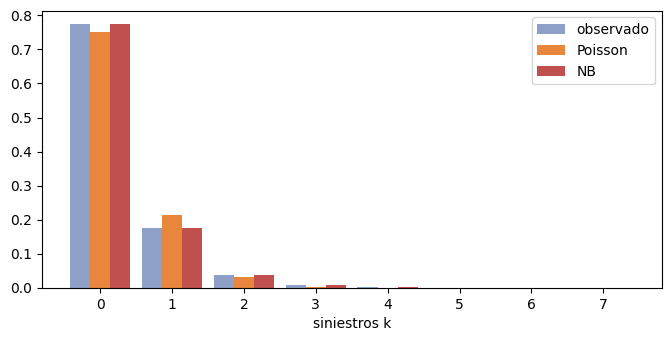

In [5]:
# ─── Observado vs. esperado bajo Poisson Y bajo NB (cierra el argumento) ───
mu = lam_hat * df.exposicion.values
kmax = y.max(); ks = np.arange(0, kmax+1)
obs   = np.bincount(y, minlength=kmax+1) / len(y)
e_po  = np.array([stats.poisson(mu).pmf(k) for k in ks]).mean(axis=1)
r = 1/alpha; p_i = r/(r+mu)
e_nb  = np.array([stats.nbinom(r, p_i).pmf(k) for k in ks]).mean(axis=1)
comp = pd.DataFrame({"k": ks, "observado": obs.round(4), "Poisson": e_po.round(4), "NB": e_nb.round(4)})
print(comp.to_string(index=False))
w=0.28
plt.bar(ks-w, obs, width=w, label="observado", color="#8FA0C8")
plt.bar(ks,   e_po, width=w, label="Poisson", color="#E8873C")
plt.bar(ks+w, e_nb, width=w, label="NB", color="#C0504D")
plt.xlabel("siniestros k"); plt.legend(); plt.show()

**Conclusión (3):** hay **sobredispersión** (φ>1) y la NB baja el AIC. En el observado-vs-esperado, la
**NB reproduce los ceros y la cola** mejor que la Poisson (que se queda corta): elijo **binomial
negativa**. No hace falta un ZIP porque la NB ya absorbe el exceso de ceros.

---
## 4. Prima pura por **dos caminos** (y a nivel producto)

La prima pura se puede obtener como **frecuencia × severidad** (modelo) o como **burning cost** (el
promedio de `monto_total`). Que coincidan valida el modelo.

In [6]:
# ─── Reconciliación: modelo vs. burning cost ───────────────────────────────
EX = dist_sev.mean(*pr_sev)                    # severidad esperada (modelo)
pp_modelo  = lam_hat * EX                        # frecuencia × severidad, por año-póliza
pp_burning = df.monto_total_siniestros.sum() / df.exposicion.sum()   # burning cost empírico

print(f"Prima pura (frecuencia × severidad) = {pp_modelo:,.0f} por año-póliza")
print(f"Prima pura (burning cost empírico)  = {pp_burning:,.0f} por año-póliza")
print(f"Diferencia = {abs(pp_modelo/pp_burning-1):.1%}  → el modelo reproduce la prima empírica")

# a nivel producto (lo que faltaba): por póliza y ajustando la transformación
expo_media = df.exposicion.mean()
print(f"\nPrima pura ground-up ≈ {pp_modelo:,.0f}/año-póliza  ≈  {pp_modelo*expo_media:,.0f} por póliza")

Prima pura (frecuencia × severidad) = 18,779 por año-póliza
Prima pura (burning cost empírico)  = 18,808 por año-póliza
Diferencia = 0.2%  → el modelo reproduce la prima empírica

Prima pura ground-up ≈ 18,779/año-póliza  ≈  15,014 por póliza


**Conclusión (4):** los dos caminos coinciden (diferencia mínima), lo que **valida** el modelo de
frecuencia y severidad. La prima pura ground-up es ≈ el burning cost; el paso que faltaba —bajarla a
**por póliza / por año-póliza**— es lo que entra en la nota técnica.

---
## 5. Simulación de S — ground-up y transformada, validada contra el agregado real

In [7]:
# ─── Simulación del modelo colectivo (M grande para estabilizar la cola) ───
Lambda = lam_hat * df.exposicion.sum()
r_agg  = Lambda/(phi-1); p_agg = r_agg/(r_agg+Lambda)
frec   = stats.nbinom(r_agg, p_agg)
ded, sa, coas = df.deducible.values, df.suma_asegurada.values, df.coaseguro.values
def transformar(x, d, c, s): return np.minimum(np.maximum(x-d,0)*(1-c), s)

M = 12000
Sg = np.empty(M); Sp = np.empty(M)
for m in range(M):
    Nt2 = frec.rvs()
    xg = dist_sev.rvs(*pr_sev, size=Nt2)
    pol = np.random.randint(0, len(df), Nt2)
    Sg[m] = xg.sum(); Sp[m] = transformar(xg, ded[pol], coas[pol], sa[pol]).sum()

agregado_real = df.monto_total_siniestros.sum()     # pérdida ground-up observada (1 año)
print(f"E[S] simulada (ground-up) = {Sg.mean():,.0f}  vs  agregado real observado = {agregado_real:,.0f}")
print(f"(coinciden → la simulación reproduce la cartera)\n")
def rt(S): v=np.percentile(S,99); return S.mean(), v, S[S>v].mean()
print(f"{'Versión':14}{'E[S]':>16}{'VaR99':>15}{'TVaR99':>15}{'recargo 99%':>14}")
for nom,S in [("Ground-up",Sg),("Transformada",Sp)]:
    e,v,t=rt(S); print(f"{nom:14}{e:>16,.0f}{v:>15,.0f}{t:>15,.0f}{v/e-1:>13.1%}")

E[S] simulada (ground-up) = 450,383,482  vs  agregado real observado = 451,099,970
(coinciden → la simulación reproduce la cartera)

Versión                   E[S]          VaR99         TVaR99   recargo 99%
Ground-up          450,383,482    468,458,774    471,320,165         4.0%
Transformada       302,579,403    316,475,145    318,655,248         4.6%


**Conclusión (5):** la E[S] simulada coincide con el agregado real observado (validación con el campo
verdadero). La **versión transformada** es la que paga la aseguradora y la que sostiene la prima del
producto. A nivel cartera el **recargo del percentil 99 es pequeño** (~pocos %): el pooling reduce el
riesgo relativo; la cola pesa en carteras chicas y en el reaseguro (Tema 5).

---
## 6. Validación contra la guía de ramos (Sesión 6)

In [8]:
print("Perfil guía (Autos)        vs.   Esta cartera")
print("-"*52)
print(f"alta frecuencia            →   λ̂ = {lam_hat:.2f}/año-póliza ✓")
print(f"severidad moderada         →   E[X] ≈ {EX:,.0f} ✓")
print(f"cola media                 →   {mejor} ✓")
print(f"Poisson/NB                 →   sobredispersión → NB ✓")

Perfil guía (Autos)        vs.   Esta cartera
----------------------------------------------------
alta frecuencia            →   λ̂ = 0.36/año-póliza ✓
severidad moderada         →   E[X] ≈ 52,409 ✓
cola media                 →   Lognormal ✓
Poisson/NB                 →   sobredispersión → NB ✓


**Conclusión (6):** la cartera es **consistente** con el perfil de mercado de autos de la guía.

---
## 7. Conclusión final

- **Severidad:** lognormal, ajustada **ponderando por número de siniestros** (más correcto a nivel cartera).
- **Frecuencia:** binomial negativa (sobredispersión confirmada por φ, AIC y el observado-vs-esperado).
- **Prima pura:** validada por dos caminos (modelo ≈ burning cost) y bajada a nivel producto.
- **S del producto:** la versión transformada; la simulación reproduce el agregado real de la cartera.
- La cartera cuadra con la guía de ramos.

*Solución avanzada · Práctica 1 · MASDFR*